# LQR baseline (continuous control)

Continuous-control baseline for comparison with the spiking controller. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

In [2]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B_lqr = np.array([[0.0], [1.0]])      # single continuous actuator on velocity

# LQR cost matrices
Q_lqr = np.diag([20.0, 1.0])
R_lqr = np.array([[0.1]])

P_lqr = solve_continuous_are(A, B_lqr, Q_lqr, R_lqr)       # solve the Riccati equation
K = np.linalg.inv(R_lqr) @ B_lqr.T @ P_lqr                 # optimal feedback gain

k_ff = -A[1, 0]    # feedforward term to hold the steady-state reference

T  = 100           # total simulated time (s)
dt = 0.01          # output sampling step
t_eval     = np.arange(0, T, dt)
z_schedule = [(5.0, 5.0), (15.0, 10.0), (30.0, 15.0)]         # (time, target) steps
x0         = [0.0, 0.0]

sigma_m = 0.5     # measurement noise
sigma_p = 0.5     # process noise

# low-pass filter the step schedule into a smooth reference z(t)
def get_target(t, z_prev, dt):
    z_base = 0.0
    for t_point, val in z_schedule:
        if t >= t_point:
            z_base = val
    return z_prev + dt * 0.5 * (z_base - z_prev)

In [3]:
np.random.seed(42)     

nT = len(t_eval)
x         = np.zeros((nT, 2))
z         = np.zeros(nT)
u_history = np.zeros(nT)
x[0]      = x0

for i in range(nT - 1):
    z[i+1] = get_target(t_eval[i], z[i], dt)
    x_ref  = np.array([z[i], 0.0])
    x_meas = x[i] + sigma_m * np.random.randn(2)        # noisy state estimate
    u = -(K @ (x_meas - x_ref))[0] + k_ff * z[i]        # LQR feedback
    u_history[i] = u

    noise_p   = sigma_p * np.random.randn(2) * np.sqrt(dt)
    x[i+1]    = x[i] + dt * (A @ x[i] + B_lqr[:, 0] * u) + noise_p

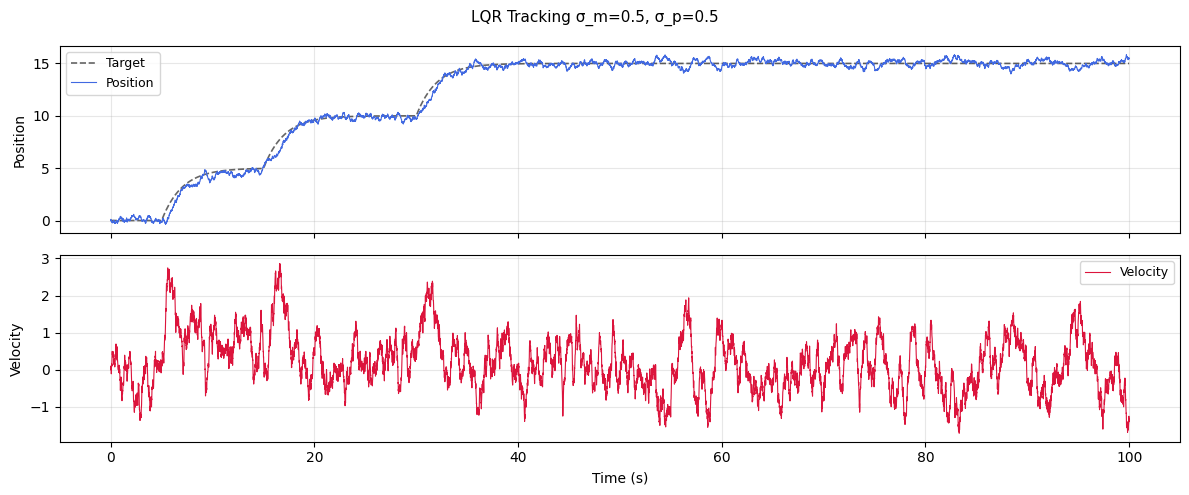

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t_eval, z,       'k--', alpha=0.6, linewidth=1.2, label='Target')
axes[0].plot(t_eval, x[:, 0], color='royalblue', linewidth=0.8, label='Position')
axes[0].set_ylabel('Position')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(t_eval, x[:, 1], color='crimson', linewidth=0.8, label='Velocity')
axes[1].set_ylabel('Velocity')
axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f'LQR Tracking σ_m={sigma_m}, σ_p={sigma_p}', fontsize=11)
plt.tight_layout()
plt.show()

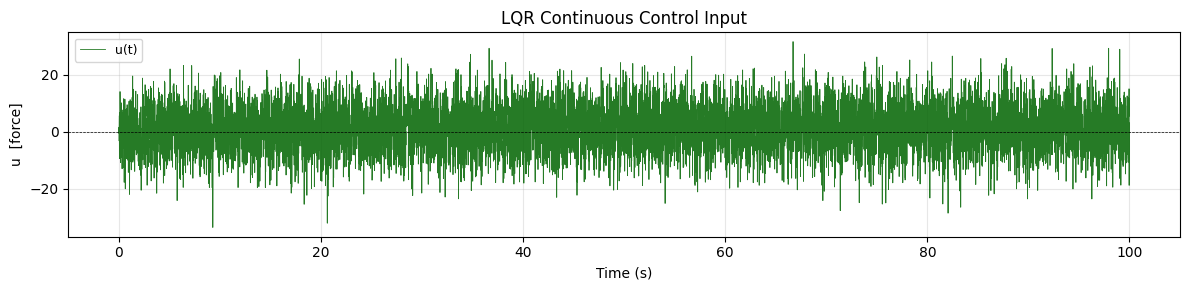

In [5]:
plt.figure(figsize=(12, 3))
plt.plot(t_eval, u_history, color='darkgreen', linewidth=0.6, alpha=0.85, label='u(t)')
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('u  [force]')
plt.title('LQR Continuous Control Input')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

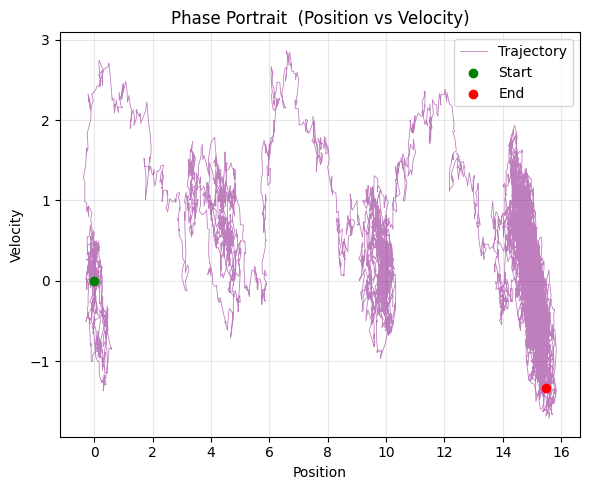

In [6]:
plt.figure(figsize=(6, 5))
plt.plot(x[:, 0], x[:, 1], color='purple', alpha=0.5, linewidth=0.6, label='Trajectory')
plt.scatter(x[0,  0], x[0,  1], color='green', zorder=5, label='Start')
plt.scatter(x[-1, 0], x[-1, 1], color='red',   zorder=5, label='End')
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Portrait  (Position vs Velocity)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cumulative error: 27.094


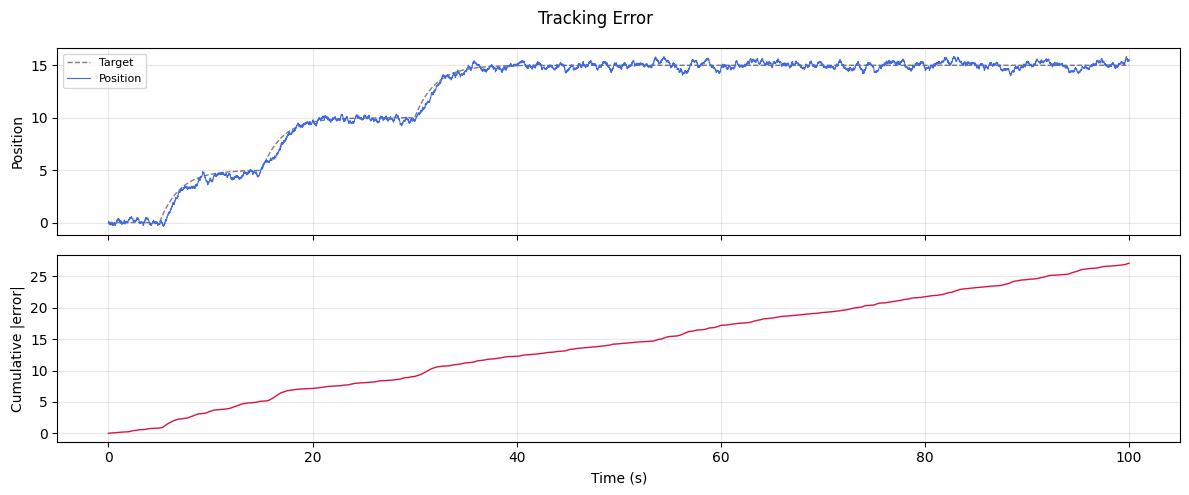

In [7]:
cumulative_error = np.cumsum(np.abs(x[:, 0] - z)) * dt

print("Cumulative error:", round(cumulative_error[-1], 3))

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t_eval, z,       'k--', alpha=0.5, linewidth=1,   label='Target')
axes[0].plot(t_eval, x[:, 0], color='royalblue', linewidth=0.8, label='Position')
axes[0].set_ylabel('Position')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(t_eval, cumulative_error, color='crimson', linewidth=1)
axes[1].set_ylabel('Cumulative |error|')
axes[1].set_xlabel('Time (s)')
axes[1].grid(alpha=0.3)

plt.suptitle('Tracking Error')
plt.tight_layout()
plt.show()